In [2]:
import osmnx as ox
import pandas as pd
import numpy as np
import os
import re
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr

import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import math
import itertools
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point
import requests
import time
from geopy.geocoders import Nominatim
import time
from shapely.wkt import dumps
from shapely.wkt import loads
from dotenv import load_dotenv
import glob

from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import re
from datetime import datetime

pd.set_option('display.precision', 4)
# Expand all columns and prevent content truncation
pd.set_option('display.max_colwidth', None)

# 1. Load dataframes

In [3]:
# Load combined_df
combined_df = pd.read_pickle("combined_light_with_busyness_level.pkl")

In [4]:
combined_df.head()

,date,hour,temp_c,dew_c,wind_speed_knot,precip_mm,grid_id,lat,lon,geometry,...,restaurant_count,subway_grid_ridership,subway_buffer_ridership,bike_grid_trips,bike_buffer_ridership,taxi_passenger_count,event_count,population,busyness_percentile,busyness_level
0,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0001,40.6840,-74.0257,"POLYGON ((-74.0242 40.68292, -74.0242 40.68517, -74.02714 40.68517, -74.02714 40.68292, -74.0242 40.68292))",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2931,1
1,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0002,40.6840,-74.0227,"POLYGON ((-74.02126 40.68292, -74.02126 40.68517, -74.0242 40.68517, -74.0242 40.68292, -74.02126 40.68292))",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2931,1
2,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0003,40.6840,-74.0198,"POLYGON ((-74.01832 40.68292, -74.01832 40.68517, -74.02126 40.68517, -74.02126 40.68292, -74.01832 40.68292))",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2931,1
3,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0004,40.6863,-74.0257,"POLYGON ((-74.0242 40.68517, -74.0242 40.68742, -74.02714 40.68742, -74.02714 40.68517, -74.0242 40.68517))",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2931,1
4,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0005,40.6863,-74.0227,"POLYGON ((-74.02126 40.68517, -74.02126 40.68742, -74.0242 40.68742, -74.0242 40.68517, -74.02126 40.68517))",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2931,1


In [5]:
# check restaurants number in every grid
grid_restaurant_static = (
    combined_df[['grid_id', 'restaurant_count']]
    .drop_duplicates(subset='grid_id')
    .set_index('grid_id')
    .sort_index()
)

grid_restaurant_static['restaurant_count'].value_counts().sort_index()


restaurant_count
0.0      465
1.0       59
2.0       45
3.0       43
4.0       44
        ... 
70.0       1
71.0       1
88.0       2
95.0       1
115.0      1
Name: count, Length: 68, dtype: int64

In [6]:
insp_df = pd.read_csv("inspection/Inspection_latest_Results_cleaned_step2.csv")

In [ ]:
popular_time_df = pd.read_csv("../data_preparation/restaurant_data_fetching/google_api_restaurant_popular_time_step2.csv")
google_place_df = pd.read_csv("../data_preparation/restaurant_data_fetching/google_api_restaurant_metadata_step2.csv")

In [8]:
popular_time_df.head()

,place_id,day,hour_0,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,ChIJ03By9lhYwokRfGgIPEcxNlM,Monday,28,28,36,38,0,0,0,0,...,47,50,47,52,49,46,52,66,63,49
1,ChIJ03By9lhYwokRfGgIPEcxNlM,Tuesday,40,38,36,29,0,0,0,0,...,26,39,46,66,60,63,54,57,61,49
2,ChIJ03By9lhYwokRfGgIPEcxNlM,Wednesday,38,35,36,47,0,0,0,0,...,36,45,52,52,39,35,45,61,81,71
3,ChIJ03By9lhYwokRfGgIPEcxNlM,Thursday,54,33,28,30,0,0,0,0,...,26,30,50,73,90,87,73,67,70,70
4,ChIJ03By9lhYwokRfGgIPEcxNlM,Friday,63,54,40,28,0,0,0,0,...,61,61,69,85,90,91,92,97,100,98


In [9]:
google_place_df.columns

Index(['full_name', 'place_id', 'name', 'rating', 'review_count', 'address',
       'lat', 'lon', 'types', 'opening_hours', 'website', 'phone', 'reviews',
       'Latitude', 'Longitude', 'rough_lat', 'rough_lng', 'clustered',
       'time_spent_min', 'time_spent_max', 'popular_data'],
      dtype='object')

In [10]:
google_place_df.head()

full_name                     place_id  \
0             D.J. REYNOLDS 351 WEST   57 STREET  ChIJ03By9lhYwokRfGgIPEcxNlM   
1  1 EAST 66TH STREET KITCHEN 1 EAST   66 STREET  ChIJYdHIa-lYwokRmeZUvOoldMo   
2         P & S DELI GROCERY 730 COLUMBUS AVENUE  ChIJ10yifCf2wokRDiZPK-60xM8   
3    ANGELIKA FILM CENTER 18 WEST HOUSTON STREET  ChIJQ1RTt49ZwokRgYgqG6DdK2w   
4                        CAFE METRO 625 8 AVENUE  ChIJQzxNYepZwokRCYqnc_ftZcc   

                                     name  rating  review_count  \
0                           D.J. Reynolds     4.3         540.0   
1               165 East 66 by Stonehenge     5.0           2.0   
2                 Paul Saini Deli Grocery     4.1          82.0   
3  Angelika Film Center & Cafe - New York     4.4        2058.0   
4                              Cafe Metro     2.9           9.0   

                                     address      lat      lon  \
0     351 W 57th St, New York, NY 10019, USA  40.7678 -73.9849   
1     165 E 66th St, New York, NY 10065, USA  40.7662 -73.9638   
2  724 Columbus Ave, New York, NY 10025, USA  40.7924 -73.9682   
3   18 W Houston St, New York, NY 10012, USA  40.7259 -73.9972   
4       625 8th Ave, New York, NY 10018, USA  40.7569 -73.9905   

                                                         types  \
0      bar, restaurant, food, point_of_interest, establishment   
1         real_estate_agency, point_of_interest, establishment   
2                food, point_of_interest, store, establishment   
3  movie_theater, cafe, point_of_interest, food, establishment   
4          cafe, food, point_of_interest, store, establishment   

                                                                                                                                                                                                opening_hours  \
0      Monday: 2:30 PM – 4:00 AM; Tuesday: 2:30 PM – 4:00 AM; Wednesday: 2:30 PM – 4:00 AM; Thursday: 2:30 PM – 4:00 AM; Friday: 11:00 AM – 4:00 AM; Saturday: 11:00 AM – 4:00 AM; Sunday: 11:00 AM – 4:00 AM   
1                               Monday: 9:00 AM – 5:00 PM; Tuesday: 9:00 AM – 5:00 PM; Wednesday: 9:00 AM – 5:00 PM; Thursday: 9:00 AM – 5:00 PM; Friday: 9:00 AM – 5:00 PM; Saturday: Closed; Sunday: Closed   
2  Monday: 6:00 AM – 11:00 PM; Tuesday: 6:00 AM – 11:00 PM; Wednesday: 6:00 AM – 11:00 PM; Thursday: 6:00 AM – 11:00 PM; Friday: 6:00 AM – 11:00 PM; Saturday: 6:00 AM – 11:00 PM; Sunday: 6:00 AM – 11:00 PM   
3                                                                                                                                                                                                         NaN   
4                                                                                                                                                                                                         NaN   

   ...           phone  \
0  ...  (212) 245-2912   
1  ...             NaN   
2  ...  (212) 932-3030   
3  ...  (212) 995-2570   
4  ...             NaN   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

# 2. Popular time processing

## 2.1 Drop duplicates records in popular_time_df

In [11]:
popular_time_df['place_id'].nunique()

365

In [12]:
counts = popular_time_df.groupby('place_id').size()

num_seven = (counts == 7).sum()
num_seven

np.int64(356)

From above we could know the current popular_time_df has some restaurants have more the 7 records. This is unusual, as each restaurant should typically have only one record per day of the week, a total of 7 records.

In [13]:
dedup_df = popular_time_df.drop_duplicates()

In [14]:
# Ensure we did not lose restaurant information
dedup_df['place_id'].nunique()

365

In [15]:
counts = dedup_df.groupby('place_id').size()

num_seven = (counts == 7).sum()
num_seven

np.int64(365)

In [16]:
popular_time_df = dedup_df

## 2.2 Mapping restaurants with grid id

In [17]:
google_place_gdf = gpd.GeoDataFrame(
    google_place_df,
    geometry=gpd.points_from_xy(google_place_df['Longitude'], google_place_df['Latitude']),
    crs="EPSG:4326"
)

grid_df = combined_df[['grid_id', 'geometry']].drop_duplicates().copy()

restaurant_with_grid = gpd.sjoin(google_place_gdf, grid_df, how="left", predicate='within')


In [18]:
restaurant_with_grid.head()

,full_name,place_id,name,rating,review_count,address,lat,lon,types,opening_hours,...,Longitude,rough_lat,rough_lng,clustered,time_spent_min,time_spent_max,popular_data,geometry,index_right,grid_id
0,D.J. REYNOLDS 351 WEST 57 STREET,ChIJ03By9lhYwokRfGgIPEcxNlM,D.J. Reynolds,4.3,540.0,"351 W 57th St, New York, NY 10019, USA",40.7678,-73.9849,"bar, restaurant, food, point_of_interest, establishment",Monday: 2:30 PM – 4:00 AM; Tuesday: 2:30 PM – 4:00 AM; Wednesday: 2:30 PM – 4:00 AM; Thursday: 2:30 PM – 4:00 AM; Friday: 11:00 AM – 4:00 AM; Saturday: 11:00 AM – 4:00 AM; Sunday: 11:00 AM – 4:00 AM,...,-73.9843,40.77,-73.98,False,NaN,NaN,False,POINT (-73.98431 40.76733),493.0,M-0494
1,1 EAST 66TH STREET KITCHEN 1 EAST 66 STREET,ChIJYdHIa-lYwokRmeZUvOoldMo,165 East 66 by Stonehenge,5.0,2.0,"165 E 66th St, New York, NY 10065, USA",40.7662,-73.9638,"real_estate_agency, point_of_interest, establishment",Monday: 9:00 AM – 5:00 PM; Tuesday: 9:00 AM – 5:00 PM; Wednesday: 9:00 AM – 5:00 PM; Thursday: 9:00 AM – 5:00 PM; Friday: 9:00 AM – 5:00 PM; Saturday: Closed; Sunday: Closed,...,-73.9696,40.77,-73.97,False,NaN,NaN,False,POINT (-73.96958 40.76855),518.0,M-0519
2,P & S DELI GROCERY 730 COLUMBUS AVENUE,ChIJ10yifCf2wokRDiZPK-60xM8,Paul Saini Deli Grocery,4.1,82.0,"724 Columbus Ave, New York, NY 10025, USA",40.7924,-73.9682,"food, point_of_interest, store, establishment",Monday: 6:00 AM – 11:00 PM; Tuesday: 6:00 AM – 11:00 PM; Wednesday: 6:00 AM – 11:00 PM; Thursday: 6:00 AM – 11:00 PM; Friday: 6:00 AM – 11:00 PM; Saturday: 6:00 AM – 11:00 PM; Sunday: 6:00 AM – 11:00 PM,...,-73.9677,40.79,-73.97,False,NaN,NaN,False,POINT (-73.96771 40.79262),726.0,M-0727
3,ANGELIKA FILM CENTER 18 WEST HOUSTON STREET,ChIJQ1RTt49ZwokRgYgqG6DdK2w,Angelika Film Center & Cafe - New York,4.4,2058.0,"18 W Houston St, New York, NY 10012, USA",40.7259,-73.9972,"movie_theater, cafe, point_of_interest, food, establishment",NaN,...,-73.9975,40.73,-74.00,False,NaN,NaN,False,POINT (-73.99748 40.72574),183.0,M-0184
4,CAFE METRO 625 8 AVENUE,ChIJQzxNYepZwokRCYqnc_ftZcc,Cafe Metro,2.9,9.0,"625 8th Ave, New York, NY 10018, USA",40.7569,-73.9905,"cafe, food, point_of_interest, store, establishment",NaN,...,-73.9906,40.76,-73.99,False,NaN,NaN,False,POINT (-73.99056 40.75619),389.0,M-0390


In [19]:
restaurant_with_grid['grid_id'].isna().sum()

np.int64(181)

There are 181 restaurants do not map with grid_id.

In [20]:
(restaurant_with_grid['geometry'].apply(lambda g: g is None or g.is_empty or g.equals(Point(0, 0)) or (hasattr(g, 'x') and (g.x != g.x or g.y != g.y)))).sum()


np.int64(181)

The restaurants that do not have `grid_id` are those without have valid geometry. We drop them for now.

In [21]:
restaurant_with_grid = restaurant_with_grid[
    restaurant_with_grid['geometry'].apply(
        lambda g: g and not g.is_empty and not g.equals(Point(0, 0)) and not (hasattr(g, 'x') and (g.x != g.x or g.y != g.y))
    )
]

In [22]:
# Check if all the restaurant map with grid_id
restaurant_with_grid['grid_id'].isna().sum()

np.int64(0)

## 2.3 Expand Weekly Popular Times to Full Date-Hour Samples

In [23]:
# wide → long， weekday + hour → pop_value
pop_long = popular_time_df.melt(
    id_vars=['place_id', 'day'], 
    value_vars=[f'hour_{i}' for i in range(24)],
    var_name='hour_str', 
    value_name='pop_value'
)
pop_long['hour'] = pop_long['hour_str'].str.extract(r'(\d+)').astype(int)
pop_long.drop(columns='hour_str', inplace=True)


In [24]:
combined_df['date'] = pd.to_datetime(combined_df['date'])

print("Earlist date:", combined_df['date'].min())
print("Latest date:", combined_df['date'].max())


Earlist date: 2024-04-01 00:00:00
Latest date: 2025-03-31 00:00:00


In [25]:
# mapping weekday ↔ date 
all_dates = pd.date_range('2024-04-01', '2025-03-31')
date_df = pd.DataFrame({'date': all_dates})
date_df['day'] = date_df['date'].dt.day_name()

# pop_long merge
pop_full = pop_long.merge(date_df, on='day', how='inner')  #  date + hour + pop_value


In [26]:
# merge grid_id into the frame
pop_full = pop_full.merge(
    restaurant_with_grid[['place_id', 'grid_id', 'geometry']],
    on='place_id',
    how='left'
)


In [27]:
# rename busyness column from grid 
grid_busyness = combined_df[['grid_id', 'date', 'hour', 'busyness_percentile', 'busyness_level']].rename(columns={
    'busyness_percentile': 'grid_busyness_percentile',
    'busyness_level': 'grid_busyness_level'
})

# merge
pop_full = pop_full.merge(grid_busyness, on=['grid_id', 'date', 'hour'], how='left')


In [28]:
pop_full.head()

,place_id,day,pop_value,hour,date,grid_id,geometry,grid_busyness_percentile,grid_busyness_level
0,ChIJ03By9lhYwokRfGgIPEcxNlM,Monday,28,0,2024-04-01,M-0494,POINT (-73.98431 40.76733),0.3853,1
1,ChIJ03By9lhYwokRfGgIPEcxNlM,Monday,28,0,2024-04-08,M-0494,POINT (-73.98431 40.76733),0.3821,1
2,ChIJ03By9lhYwokRfGgIPEcxNlM,Monday,28,0,2024-04-15,M-0494,POINT (-73.98431 40.76733),0.4019,1
3,ChIJ03By9lhYwokRfGgIPEcxNlM,Monday,28,0,2024-04-22,M-0494,POINT (-73.98431 40.76733),0.3932,1
4,ChIJ03By9lhYwokRfGgIPEcxNlM,Monday,28,0,2024-04-29,M-0494,POINT (-73.98431 40.76733),0.3933,1


In [29]:
# Check the grid busyness info are correctly merged into the pop_full
combined_df.loc[
    (combined_df['grid_id'] == 'M-0494') &
    ((combined_df['date'] == '2024-04-01') |  (combined_df['date'] == '2024-04-08'))&
    (combined_df['hour'] == 0),
    ['date', 'grid_id', 'busyness_percentile', 'busyness_level']
]


,date,grid_id,busyness_percentile,busyness_level
493,2024-04-01,M-0494,0.3853,1
192013,2024-04-08,M-0494,0.3821,1


## 2.4 Calculate combined_score for restaurant in pop_full 

In [30]:
pop_full['combined_score'] = (
    0.7 * pop_full['pop_value'] + 0.3 * pop_full['grid_busyness_percentile']
)

min_val = pop_full['combined_score'].min()
max_val = pop_full['combined_score'].max()

bin_edges = np.linspace(min_val, max_val, 6)


pop_full['busyness_level'] = pd.cut(
    pop_full['combined_score'],
    bins=bin_edges,
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
)

In [31]:
pop_full.head()

,place_id,day,pop_value,hour,date,grid_id,geometry,grid_busyness_percentile,grid_busyness_level,combined_score,busyness_level
0,ChIJ03By9lhYwokRfGgIPEcxNlM,Monday,28,0,2024-04-01,M-0494,POINT (-73.98431 40.76733),0.3853,1,19.7156,2
1,ChIJ03By9lhYwokRfGgIPEcxNlM,Monday,28,0,2024-04-08,M-0494,POINT (-73.98431 40.76733),0.3821,1,19.7146,2
2,ChIJ03By9lhYwokRfGgIPEcxNlM,Monday,28,0,2024-04-15,M-0494,POINT (-73.98431 40.76733),0.4019,1,19.7206,2
3,ChIJ03By9lhYwokRfGgIPEcxNlM,Monday,28,0,2024-04-22,M-0494,POINT (-73.98431 40.76733),0.3932,1,19.7180,2
4,ChIJ03By9lhYwokRfGgIPEcxNlM,Monday,28,0,2024-04-29,M-0494,POINT (-73.98431 40.76733),0.3933,1,19.7180,2


In [32]:
pop_full['busyness_level'].value_counts()

busyness_level
1    1639567
3     594838
2     459888
4     409770
5     189697
Name: count, dtype: int64

## 2.5 Visualization

### 2.5.1 Restaurants on the map

In [33]:
# base map
combined_df['geometry'] = combined_df['geometry'].apply(lambda g: g if g is not None and not g.is_empty else None)
grid_gdf = combined_df[['grid_id', 'geometry']].drop_duplicates().copy()
grid_gdf = gpd.GeoDataFrame(grid_gdf, geometry='geometry', crs='EPSG:4326')  


grid_gdf = grid_gdf.to_crs(epsg=3857)


In [34]:
restaurant_gdf = restaurant_with_grid.copy()
restaurant_gdf = restaurant_gdf.to_crs(epsg=3857)


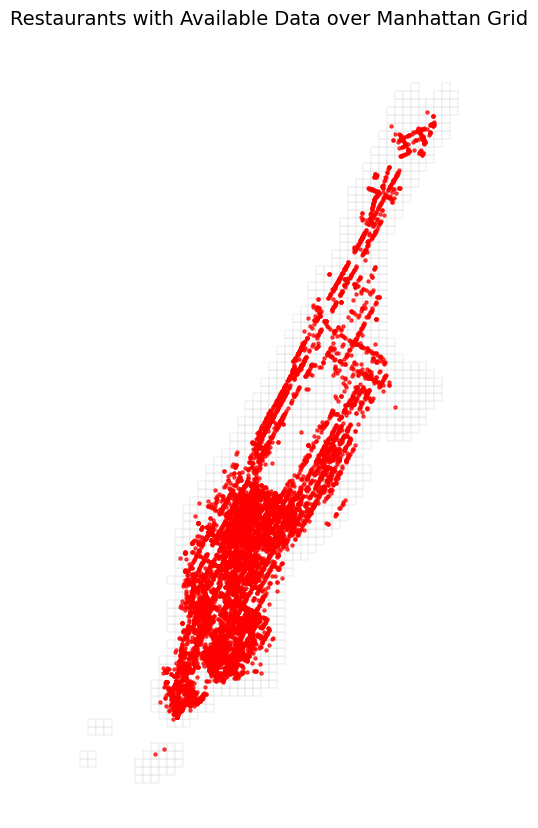

In [35]:
fig, ax = plt.subplots(figsize=(10, 10))

# base map grid
grid_gdf.plot(ax=ax, edgecolor='lightgrey', facecolor='white', linewidth=0.3)

# restaurant dot
restaurant_gdf.plot(ax=ax, color='red', markersize=5, alpha=0.7)

ax.set_title("Restaurants with Available Data over Manhattan Grid", fontsize=14)
ax.axis('off')
plt.show()


### 2.5.2 popular time

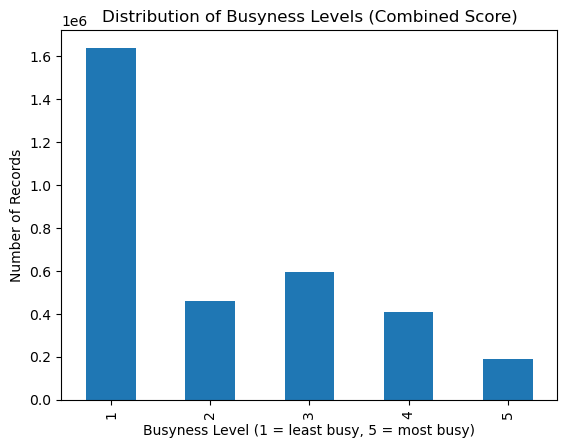

In [36]:
pop_full['busyness_level'] = pop_full['busyness_level'].astype(int)  # convert to int to sort
pop_full['busyness_level'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Busyness Level (1 = least busy, 5 = most busy)')
plt.ylabel('Number of Records')
plt.title('Distribution of Busyness Levels (Combined Score)')
plt.show()


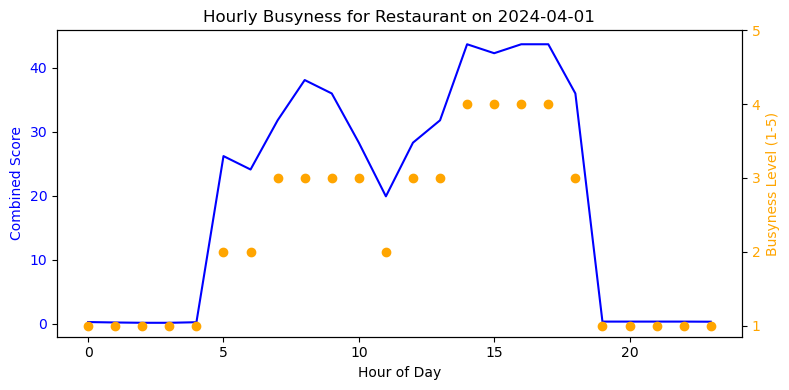

In [37]:
fig, ax1 = plt.subplots(figsize=(8, 4))
example_df = pop_full[(pop_full['place_id'] == 'ChIJn84RP29ZwokR-ugKkdBspSo') &
                      (pop_full['date'] == '2024-04-01')]
# ax1 for combined score
ax1.plot(example_df['hour'], example_df['combined_score'], color='blue', label='Combined Score')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Combined Score', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# ax2 for busyness level
ax2 = ax1.twinx()
ax2.scatter(example_df['hour'], example_df['busyness_level'].astype(int), color='orange', label='Busyness Level (1–5)')
ax2.set_ylabel('Busyness Level (1-5)', color='orange')
ax2.set_yticks([1, 2, 3, 4, 5])
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Hourly Busyness for Restaurant on 2024-04-01')
fig.tight_layout()
plt.show()


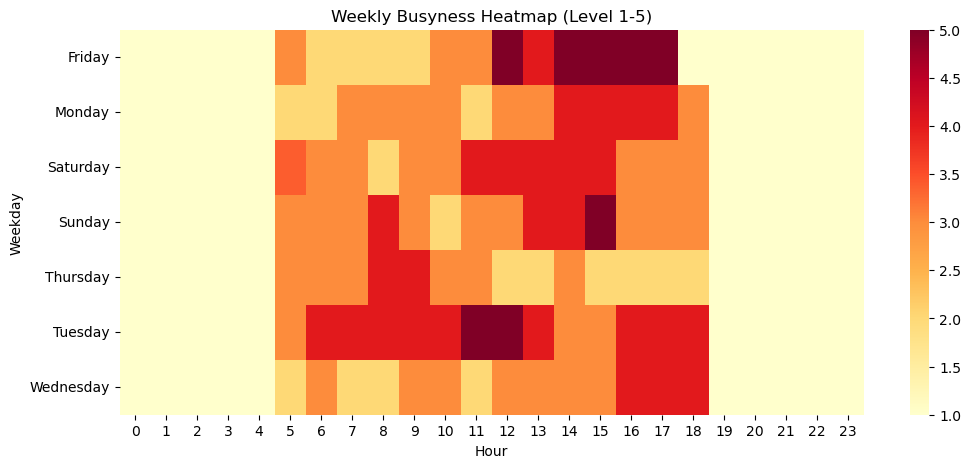

In [38]:
# random sample
sample = pop_full[pop_full['place_id'] == 'ChIJn84RP29ZwokR-ugKkdBspSo']
# weekday + hour 
heatmap_data = sample.pivot_table(index='day', columns='hour', values='busyness_level')

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False)
plt.title('Weekly Busyness Heatmap (Level 1-5)')
plt.xlabel('Hour')
plt.ylabel('Weekday')
plt.show()


In [39]:
def plot_discrete_busyness_map(pop_full, date_str, hour_int, figsize=(6, 6), cmap='OrRd'):
    # 1. Filter the data
    df_hour = pop_full[(pop_full['date'] == date_str) & (pop_full['hour'] == hour_int)].copy()

    # 2. Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(df_hour, geometry='geometry', crs='EPSG:4326').to_crs(epsg=3857)
    gdf = gdf.dropna(subset=['busyness_level'])

    # 3. Plot using discrete categories
    fig, ax = plt.subplots(figsize=figsize)
    gdf.plot(
        ax=ax,
        column='busyness_level',
        cmap=cmap,
        markersize=30,
        categorical=True,
        legend=True,
        legend_kwds={'loc': 'upper left', 'title': 'Busyness Level'}
    )

    ax.set_title(f"Busyness Map - {date_str} {hour_int:02d}:00", fontsize=12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


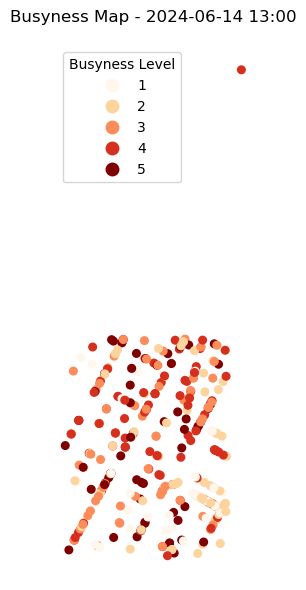

In [40]:
plot_discrete_busyness_map(pop_full, '2024-06-14', 13)


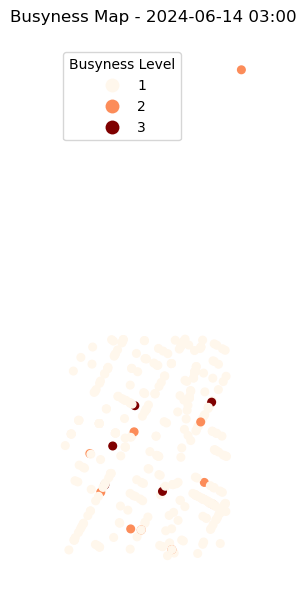

In [41]:
plot_discrete_busyness_map(pop_full, '2024-06-14', 3)

# 3. Map `insp_df` with `google_place_df`

In [42]:
insp_df['full_name'] = insp_df['DBA'].str.strip() + ' ' + insp_df['BUILDING'].astype(str).str.strip() + ' ' + insp_df['STREET'].str.strip()

In [43]:
# merge CAMIS
restaurant_with_grid_camis = pd.merge(
    restaurant_with_grid,
    insp_df[['CAMIS', 'full_name']],
    on='full_name',
    how='left'
)

In [44]:
restaurant_with_grid_camis['CAMIS'].isna().sum()

np.int64(0)

In [45]:
restaurant_with_grid_camis.shape

(10416, 25)

## check pop value

In [47]:
# Extract unique place_ids where popular_data is True
popular_place_ids = restaurant_with_grid_camis.loc[restaurant_with_grid_camis["popular_data"] == True, "place_id"].dropna().unique()

# Extract unique place_ids from pop_full
pop_place_ids = pop_full["place_id"].dropna().unique()

# Identify place_ids that are missing in pop_full
missing_place_ids = [pid for pid in popular_place_ids if pid not in pop_place_ids]

# Print summary
print(f"Total with popular_data == True: {len(popular_place_ids)}")
print(f"Missing in pop_full: {len(missing_place_ids)}")

restaurant_with_grid_camis["popular_data_check"] = restaurant_with_grid_camis["place_id"].isin(pop_place_ids)

Total with popular_data == True: 558
Missing in pop_full: 194


In [48]:
restaurant_with_grid_camis.shape

(10416, 26)

In [49]:
restaurant_with_grid_camis['CAMIS'].nunique()

10416

In [50]:
restaurant_with_grid_camis[['CAMIS','opening_hours']].head(10)

,CAMIS,opening_hours
0,30191841,Monday: 2:30 PM – 4:00 AM; Tuesday: 2:30 PM – 4:00 AM; Wednesday: 2:30 PM – 4:00 AM; Thursday: 2:30 PM – 4:00 AM; Friday: 11:00 AM – 4:00 AM; Saturday: 11:00 AM – 4:00 AM; Sunday: 11:00 AM – 4:00 AM
1,40359480,Monday: 9:00 AM – 5:00 PM; Tuesday: 9:00 AM – 5:00 PM; Wednesday: 9:00 AM – 5:00 PM; Thursday: 9:00 AM – 5:00 PM; Friday: 9:00 AM – 5:00 PM; Saturday: Closed; Sunday: Closed
2,40362264,Monday: 6:00 AM – 11:00 PM; Tuesday: 6:00 AM – 11:00 PM; Wednesday: 6:00 AM – 11:00 PM; Thursday: 6:00 AM – 11:00 PM; Friday: 6:00 AM – 11:00 PM; Saturday: 6:00 AM – 11:00 PM; Sunday: 6:00 AM – 11:00 PM
3,40362274,NaN
4,40363298,NaN
5,40364179,Monday: Closed; Tuesday: 2:30 – 8:30 PM; Wednesday: 2:30 – 8:30 PM; Thursday: 2:30 – 8:30 PM; Friday: 2:30 – 8:30 PM; Saturday: 2:30 – 8:30 PM; Sunday: 2:30 – 8:30 PM
6,40364347,Monday: Open 24 hours; Tuesday: Open 24 hours; Wednesday: Open 24 hours; Thursday: Open 24 hours; Friday: Open 24 hours; Saturday: Open 24 hours; Sunday: Open 24 hours
7,41232890,Monday: Open 24 hours; Tuesday: Open 24 hours; Wednesday: Open 24 hours; Thursday: Open 24 hours; Friday: Open 24 hours; Saturday: Open 24 hours; Sunday: Open 24 hours
8,40364373,Monday: 11:30 AM – 10:00 PM; Tuesday: 11:30 AM – 10:00 PM; Wednesday: 11:30 AM – 10:00 PM; Thursday: 11:30 AM – 10:00 PM; Friday: 11:30 AM – 10:00 PM; Saturday: 11:30 AM – 10:00 PM; Sunday: Closed
9,40364389,Monday: 11:30 AM – 12:00 AM; Tuesday: 11:30 AM – 12:30 AM; Wednesday: 11:30 AM – 12:30 AM; Thursday: 11:30 AM – 12:30 AM; Friday: 11:30 AM – 12:30 AM; Saturday: 11:30 AM – 12:30 AM; Sunday: 12:00 – 10:00 PM


# 4. Calculate restaurant busyness_level

## 4.1.1 Review counts weighted grid busyness

In [51]:

# Function to parse the 'opening_hours' string into a set of (weekday, hour) pairs
def parse_opening_hours(opening_hours_str):
    # Map weekday names to numbers: Monday=1, ..., Sunday=7
    day_map = {
        'Monday': 1, 'Tuesday': 2, 'Wednesday': 3,
        'Thursday': 4, 'Friday': 5, 'Saturday': 6, 'Sunday': 7
    }
    result = set()
    for day, day_idx in day_map.items():
        pattern = re.search(f'{day}:\s*([^;]+)', opening_hours_str)
        if pattern:
            times = pattern.group(1)
            if 'Open 24 hours' in times:
                result.update((day_idx, h) for h in range(24))
            else:
                time_ranges = times.split(', ')
                for time_range in time_ranges:
                    match = re.match(r'(\d{1,2}:\d{2})\s*(AM|PM)[^\d]+(\d{1,2}:\d{2})\s*(AM|PM)', time_range)
                    if match:
                        start_str, start_period, end_str, end_period = match.groups()
                        start_hour = datetime.strptime(f'{start_str} {start_period}', '%I:%M %p').hour
                        end_hour = datetime.strptime(f'{end_str} {end_period}', '%I:%M %p').hour
                        if end_hour <= start_hour:
                            end_hour += 24  # Handle overnight hours
                        result.update((day_idx, h % 24) for h in range(start_hour, end_hour))
    return result

# Function to compute estimated hourly busyness per restaurant for a specific date
def estimate_restaurant_hourly_busyness(restaurant_df, busyness_df, date_str):
    """
    Estimate hourly busyness for each restaurant on a given date.

    Parameters:
        restaurant_df (DataFrame): Contains 'CAMIS', 'grid_id', 'review_count', 'opening_hours'.
        busyness_df (DataFrame): Contains 'date', 'hour', 'grid_id', 'busyness_percentile'.
        date_str (str): Target date in 'YYYY-MM-DD' format.

    Returns:
        DataFrame with columns: CAMIS, date, hour, estimated_busyness
    """
    # Convert input date string to datetime object
    date_obj = pd.to_datetime(date_str)
    weekday = date_obj.weekday() + 1  # Map Monday=1, ..., Sunday=7

    # Expand restaurants into rows per hour if open
    expanded_rows = []
    for _, row in restaurant_df.iterrows():
        try:
            hours_open = parse_opening_hours(row['opening_hours'])
        except:
            hours_open = set()
        for hour in range(24):
            if (weekday, hour) in hours_open:
                expanded_rows.append({
                    'CAMIS': row['CAMIS'],
                    'grid_id': row['grid_id'],
                    'review_count': row['review_count'],
                    'date': date_obj,
                    'hour': hour
                })

    restaurant_open_df = pd.DataFrame(expanded_rows)

    # Merge hourly restaurant data with grid-level busyness
    merged_df = restaurant_open_df.merge(
        busyness_df[['grid_id', 'date', 'hour', 'busyness_percentile']],
        on=['grid_id', 'date', 'hour'],
        how='left'
    )

    # Calculate weighted busyness using review count
    merged_df['weight'] = merged_df['review_count']
    merged_df['busyness_weighted'] = merged_df['busyness_percentile'] * merged_df['weight']

    # Normalize by total review count within each grid-hour group
    merged_df['weight_sum'] = merged_df.groupby(['grid_id', 'date', 'hour'])['weight'].transform('sum')
    merged_df['estimated_busyness'] = merged_df['busyness_weighted'] / merged_df['weight_sum']

    # Return result
    return merged_df[['CAMIS', 'date', 'hour', 'estimated_busyness']].dropna()


In [52]:
result_df = estimate_restaurant_hourly_busyness(restaurant_with_grid_camis, combined_df, "2024-06-14")


In [53]:
# result_df.to_csv("estimate.csv")

In [54]:
from tqdm import tqdm
from datetime import datetime

# Ensure 'date' column is in datetime format
combined_df['date'] = pd.to_datetime(combined_df['date'])

# Define target date range
start_date = pd.to_datetime("2024-04-01")
end_date = pd.to_datetime("2025-03-31")

# Extract list of unique dates
date_list = combined_df['date'].dropna().dt.date.unique()

# Initialize results list
all_results = []

# Iterate through each day, estimate hourly busyness for all restaurants
for date in tqdm(date_list, desc="Computing full-year restaurant busyness"):
    try:
        daily_result = estimate_restaurant_hourly_busyness(
            restaurant_with_grid_camis, combined_df, str(date)
        )
        all_results.append(daily_result)
    except Exception as e:
        print(f"Skipped {date} due to error: {e}")

# Combine all daily estimates
full_year_result = pd.concat(all_results, ignore_index=True)

Computing full-year restaurant busyness: 100%|██████████| 365/365 [13:00<00:00,  2.14s/it]


In [55]:
# Assign busyness level 1-5 directly at the hourly level
min_val = full_year_result['estimated_busyness'].min()
max_val = full_year_result['estimated_busyness'].max()
step = (max_val - min_val) / 5
bin_edges = [min_val + i * step for i in range(6)]

full_year_result['busyness_level'] = pd.cut(
    full_year_result['estimated_busyness'],
    bins=bin_edges,
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
).astype(int)

In [56]:
full_year_result['busyness_level'].value_counts()

busyness_level
5    179149
3    117246
4    111523
2     95876
1     73322
Name: count, dtype: int64

## 4.1.2 Compared to popular time busyness_level

In [57]:
full_year_result.columns

Index(['CAMIS', 'date', 'hour', 'estimated_busyness', 'busyness_level'], dtype='object')

In [58]:
pop_full.columns

Index(['place_id', 'day', 'pop_value', 'hour', 'date', 'grid_id', 'geometry',
       'grid_busyness_percentile', 'grid_busyness_level', 'combined_score',
       'busyness_level'],
      dtype='object')

In [59]:
restaurant_with_grid_camis.columns

Index(['full_name', 'place_id', 'name', 'rating', 'review_count', 'address',
       'lat', 'lon', 'types', 'opening_hours', 'website', 'phone', 'reviews',
       'Latitude', 'Longitude', 'rough_lat', 'rough_lng', 'clustered',
       'time_spent_min', 'time_spent_max', 'popular_data', 'geometry',
       'index_right', 'grid_id', 'CAMIS', 'popular_data_check'],
      dtype='object')

In [60]:
# full_year_result.to_pickle("restaurant_full_year_result.pkl")

In [ ]:
# Filter only restaurants with popular_data_check == True
popular_restaurants = restaurant_with_grid_camis[restaurant_with_grid_camis['popular_data_check']]

# Merge with pop_full to to get every(CAMIS, date, hour)pop busyness_level
pop_subset = pop_full[['place_id', 'date', 'hour', 'busyness_level']].drop_duplicates()
pop_with_camis = pd.merge(
    popular_restaurants[['CAMIS', 'place_id']],
    pop_subset,
    on='place_id',
    how='inner'
)

# Merge with full_year_result
comparison_df = pd.merge(
    pop_with_camis,
    full_year_result[['CAMIS', 'date', 'hour', 'busyness_level']].rename(columns={'busyness_level': 'estimated_busyness_level'}),
    on=['CAMIS', 'date', 'hour'],
    how='inner'
)

# compare two df
def compare_levels(row):
    diff = abs(row['busyness_level'] - row['estimated_busyness_level'])
    if diff == 0:
        return 'match'
    elif diff == 1:
        return 'off_by_1'
    else:
        return 'mismatch'

comparison_df['busyness_comparison'] = comparison_df.apply(compare_levels, axis=1)

# Print accuracy
# Count absolute numbers and proportions
count_stats = comparison_df['busyness_comparison'].value_counts()
proportion_stats = comparison_df['busyness_comparison'].value_counts(normalize=True) * 100

# Combine into one DataFrame for clarity
accuracy_summary = pd.DataFrame({
    'count': count_stats,
    'proportion (%)': proportion_stats.round(2)
}).reset_index().rename(columns={'index': 'comparison_result'})

print("Busyness level comparison summary:")
print(accuracy_summary)



Busyness level comparison summary:
  busyness_comparison  count  proportion (%)
0            mismatch  12522           59.73
1            off_by_1   5501           26.24
2               match   2943           14.04


## 4.2.1 Baseline - assign busyness_percentile directly to each restaurant based on its grid and hour.

In [62]:
def estimate_restaurant_busyness_baseline(restaurant_df, busyness_df, date_str):
    """
    Baseline: assign busyness_percentile directly to each restaurant based on its grid and hour.

    Parameters:
        restaurant_df (DataFrame): Contains 'CAMIS', 'grid_id', 'opening_hours'.
        busyness_df (DataFrame): Contains 'date', 'hour', 'grid_id', 'busyness_percentile'.
        date_str (str): Target date in 'YYYY-MM-DD' format.

    Returns:
        DataFrame with columns: CAMIS, date, hour, estimated_busyness
    """
    date_obj = pd.to_datetime(date_str)
    weekday = date_obj.weekday() + 1  # Monday = 1

    # Expand each restaurant's open hours
    expanded_rows = []
    for _, row in restaurant_df.iterrows():
        try:
            hours_open = parse_opening_hours(row['opening_hours'])  # set of (weekday, hour)
        except:
            hours_open = set()
        for hour in range(24):
            if (weekday, hour) in hours_open:
                expanded_rows.append({
                    'CAMIS': row['CAMIS'],
                    'grid_id': row['grid_id'],
                    'date': date_obj,
                    'hour': hour
                })

    open_df = pd.DataFrame(expanded_rows)

    # Merge: directly assign grid-level busyness_percentile
    merged_df = open_df.merge(
        busyness_df[['grid_id', 'date', 'hour', 'busyness_percentile']],
        on=['grid_id', 'date', 'hour'],
        how='left'
    )

    # Direct assignment as estimated busyness
    merged_df['estimated_busyness'] = merged_df['busyness_percentile']

    return merged_df[['CAMIS', 'date', 'hour', 'estimated_busyness']].dropna()


In [63]:
baseline_results = []

for date in tqdm(date_list, desc="Computing baseline restaurant busyness"):
    try:
        baseline_daily = estimate_restaurant_busyness_baseline(
            restaurant_with_grid_camis, combined_df, str(date)
        )
        baseline_results.append(baseline_daily)
    except Exception as e:
        print(f"Skipped {date} due to error: {e}")

baseline_full_year_result = pd.concat(baseline_results, ignore_index=True)


Computing baseline restaurant busyness: 100%|██████████| 365/365 [12:20<00:00,  2.03s/it]


In [64]:
busyness_min = baseline_full_year_result['estimated_busyness'].min()
busyness_max = baseline_full_year_result['estimated_busyness'].max()

# 5 level
bins = np.linspace(busyness_min, busyness_max, 6)  

baseline_full_year_result['busyness_level'] = pd.cut(
    baseline_full_year_result['estimated_busyness'],
    bins=bins,
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
).astype(int)


## 4.2.2 Compared to popular time busyness_level

In [ ]:
# Filter only restaurants with popular_data_check == True
popular_restaurants = restaurant_with_grid_camis[restaurant_with_grid_camis['popular_data_check']]

# Merge with pop_full to gain every(CAMIS, date, hour) pop busyness_level
pop_subset = pop_full[['place_id', 'date', 'hour', 'busyness_level']].drop_duplicates()
pop_with_camis = pd.merge(
    popular_restaurants[['CAMIS', 'place_id']],
    pop_subset,
    on='place_id',
    how='inner'
)

# merge with full_year_result
comparison_df = pd.merge(
    pop_with_camis,
    baseline_full_year_result[['CAMIS', 'date', 'hour', 'busyness_level']].rename(columns={'busyness_level': 'estimated_busyness_level'}),
    on=['CAMIS', 'date', 'hour'],
    how='inner'
)

# compare two df
def compare_levels(row):
    diff = abs(row['busyness_level'] - row['estimated_busyness_level'])
    if diff == 0:
        return 'match'
    elif diff == 1:
        return 'off_by_1'
    else:
        return 'mismatch'

comparison_df['busyness_comparison'] = comparison_df.apply(compare_levels, axis=1)

# Print accuracy
# Count absolute numbers and proportions
count_stats = comparison_df['busyness_comparison'].value_counts()
proportion_stats = comparison_df['busyness_comparison'].value_counts(normalize=True) * 100

# Combine into one DataFrame for clarity
accuracy_summary_baseline = pd.DataFrame({
    'count': count_stats,
    'proportion (%)': proportion_stats.round(2)
}).reset_index().rename(columns={'index': 'comparison_result'})

print("Busyness level comparison summary:")
print(accuracy_summary_baseline)



Busyness level comparison summary:
  busyness_comparison  count  proportion (%)
0            mismatch  10410           49.65
1            off_by_1   6330           30.19
2               match   4226           20.16
